# ILUSTR 2 — Lokalność zbieżności: obszary zbieżności i 4 klasyczne niepowodzenia Newtona

Wykładnik $\rho$ i stała $C$ z poprzedniego notebooka opisują wyłącznie zachowanie **asymptotyczne, w otoczeniu rozwiązania** -- nie mówią nic o tym, czy metoda w ogóle zbiegnie z danego punktu startowego. To jest właśnie **lokalność** zbieżności: dwa punkty startowe leżące blisko siebie mogą prowadzić do zupełnie różnych losów iteracji.

W tym notebooku pokazujemy to na dwa sposoby: (1) cztery klasyczne, pojedyncze przypadki niepowodzeń metody Newtona, oraz (2) pełne "mapy" pokazujące, do którego rozwiązania (albo do żadnego) zbiega Newton w zależności od punktu startowego -- tzw. **obszary zbieżności**.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def newton_krok_po_kroku(f, df, x0, imax=8, tol=1e-12, cap=1e8):
    # Newton z pełną historią iteracji -- do rysowania stycznych krok po kroku.
    xs = [x0]
    for _ in range(imax):
        x = xs[-1]
        d = df(x)
        if d == 0:
            return np.array(xs), 'derivative_zero'
        x_new = x - f(x) / d
        if not np.isfinite(x_new) or abs(x_new) > cap:
            xs.append(x_new)
            return np.array(xs), 'diverged'
        xs.append(x_new)
        if abs(x_new - x) < tol:
            return np.array(xs), 'converged'
    return np.array(xs), 'brak_zbieznosci_w_limicie'

def rysuj_styczne(f, xs, xlim, ax, tytul):
    # Rysuje funkcję f oraz kolejne styczne kroki metody Newtona (klasyczny "schodkowy" diagram).
    t = np.linspace(xlim[0], xlim[1], 400)
    ax.plot(t, f(t), 'b-', linewidth=1.5)
    ax.axhline(0, color='k', linewidth=0.8)
    n = min(len(xs) - 1, 4)   # rysujemy maks. 4 pierwsze kroki, żeby diagram był czytelny
    for i in range(n):
        x_i = xs[i]
        if not np.isfinite(x_i) or abs(x_i) > xlim[1] * 5:
            break
        ax.plot([x_i, x_i], [0, f(x_i)], 'r--', linewidth=0.8)
        ax.plot(x_i, f(x_i), 'ro', markersize=4)
        ax.annotate(f'$x_{i}$', (x_i, 0), textcoords="offset points", xytext=(0, -12), fontsize=8, color='r')
    ax.set_xlim(xlim)
    ax.grid(True, alpha=0.4)
    ax.set_title(tytul, fontsize=10)

## Cztery klasyczne przypadki niepowodzeń

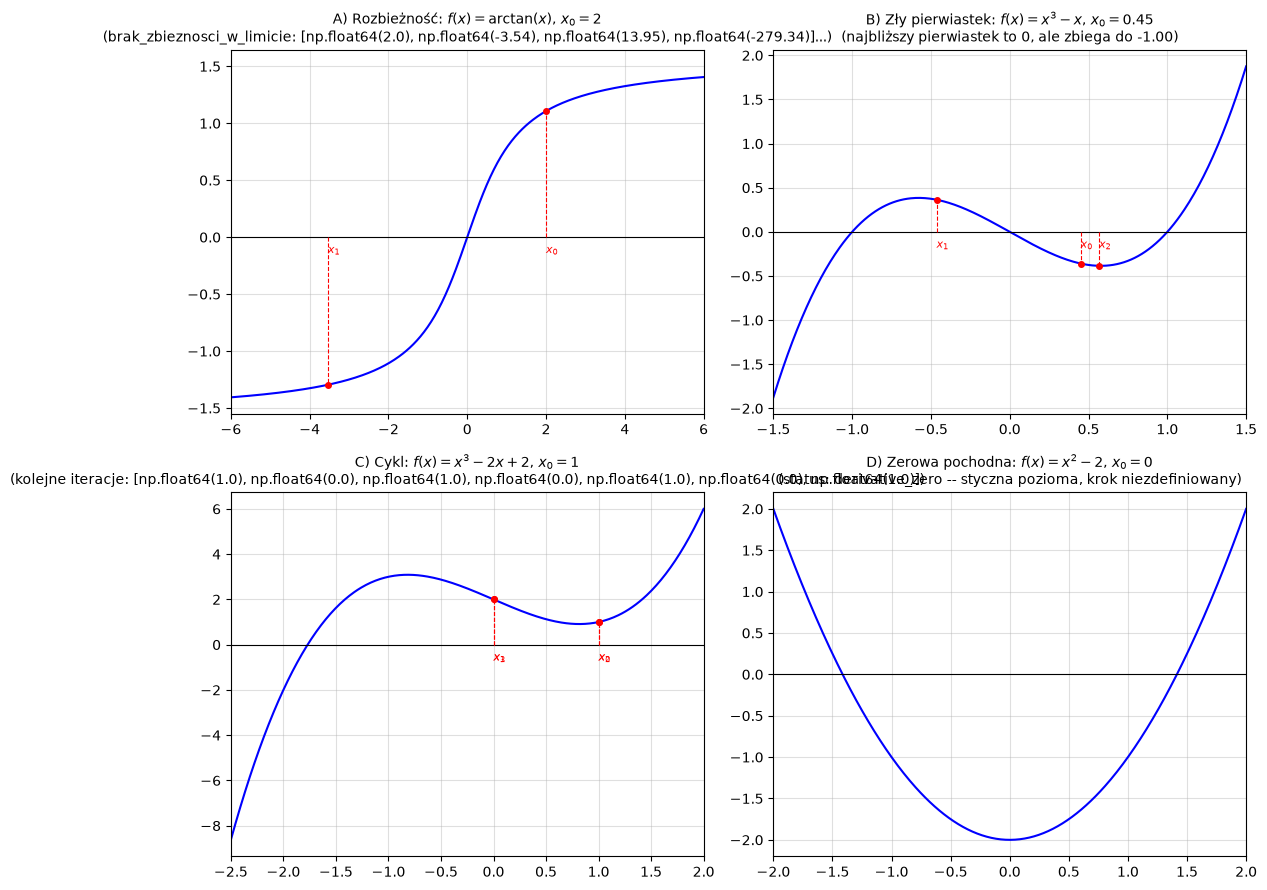

A) rozbieżność    -- pierwsze iteracje: [ 2.00000000e+00 -3.53574359e+00  1.39509591e+01 -2.79344067e+02
  1.22016999e+05]
C) cykl            -- pełna historia:   [1. 0. 1. 0. 1. 0. 1.]
D) zerowa pochodna -- f'(x0) = 0.0 -> dzielenie przez zero


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# --- Przypadek A: rozbieżność (arctan, x0 za daleko od pierwiastka) ---
fA = lambda x: np.arctan(x)
dfA = lambda x: 1 / (1 + x**2)
xsA, statusA = newton_krok_po_kroku(fA, dfA, x0=2.0, imax=4)
rysuj_styczne(fA, xsA, (-6, 6), axes[0, 0], f'A) Rozbieżność: $f(x)=\\arctan(x)$, $x_0=2$\n({statusA}: {[round(v,2) for v in xsA[:4]]}...)')

# --- Przypadek B: zbieżność do "nieoczekiwanego" pierwiastka ---
fB = lambda x: x**3 - x
dfB = lambda x: 3*x**2 - 1
xsB, statusB = newton_krok_po_kroku(fB, dfB, x0=0.45, imax=15)
rysuj_styczne(fB, xsB, (-1.5, 1.5), axes[0, 1],
              f'B) Zły pierwiastek: $f(x)=x^3-x$, $x_0=0.45$\n(najbliższy pierwiastek to 0, ale zbiega do {xsB[-1]:.2f})')

# --- Przypadek C: cykl ---
fC = lambda x: x**3 - 2*x + 2
dfC = lambda x: 3*x**2 - 2
xsC, statusC = newton_krok_po_kroku(fC, dfC, x0=1.0, imax=6)
rysuj_styczne(fC, xsC, (-2.5, 2), axes[1, 0], f'C) Cykl: $f(x)=x^3-2x+2$, $x_0=1$\n(kolejne iteracje: {[round(v,2) for v in xsC]})')

# --- Przypadek D: zerowa pochodna w punkcie startowym ---
fD = lambda x: x**2 - 2
dfD = lambda x: 2*x
xsD, statusD = newton_krok_po_kroku(fD, dfD, x0=0.0, imax=4)
rysuj_styczne(fD, xsD, (-2, 2), axes[1, 1], f'D) Zerowa pochodna: $f(x)=x^2-2$, $x_0=0$\n(status: {statusD} -- styczna pozioma, krok niezdefiniowany)')

plt.tight_layout()
plt.show()

print("A) rozbieżność    -- pierwsze iteracje:", xsA[:5])
print("C) cykl            -- pełna historia:  ", xsC)
print("D) zerowa pochodna -- f'(x0) =", dfD(0.0), "-> dzielenie przez zero")

Wszystkie cztery przypadki dotyczą tej samej metody, różnią się tylko funkcją i/lub punktem startowym -- to jest właśnie **lokalność**: wykładnik zbieżności $\rho=2$ z poprzedniego notebooka jest prawdziwy tylko *pod warunkiem*, że iteracja w ogóle dotrze do sąsiedztwa pierwiastka. Przypadek B jest szczególnie pouczający: punkt startowy $x_0=0{,}45$ jest bliżej pierwiastka $0$ niż pierwiastka $-1$, a mimo to metoda zbiega do tego drugiego -- odległość do pierwiastka **nie wystarcza**, żeby przewidzieć, dokąd zbiegnie Newton.

## Obszar zbieżności: który pierwiastek "wygrywa" w zależności od $x_0$?

Skoro odległość do pierwiastka nie wystarcza, zbadajmy to systematycznie: dla funkcji $f(x)=x^3-x$ (pierwiastki $-1,\,0,\,1$) uruchamiamy Newtona z bardzo wielu punktów startowych $x_0\in[-2,2]$ i kolorujemy każdy punkt według tego, do którego pierwiastka (albo "brak zbieżności") doprowadził.

In [ ]:
def klasyfikuj_start(f, df, x0, korzenie, imax=80, tol=1e-10, cap=1e6):
    x = x0
    for _ in range(imax):
        d = df(x)
        if d == 0:
            return -1  # brak zbieżności (zerowa pochodna po drodze)
        x_new = x - f(x) / d
        if not np.isfinite(x_new) or abs(x_new) > cap:
            return -1  # rozbieżność
        if abs(x_new - x) < tol:
            odleglosci = np.abs(np.array(korzenie) - x_new)
            return int(np.argmin(odleglosci)) if np.min(odleglosci) < 1e-4 else -1
        x = x_new
    return -1

korzenie = [-1.0, 0.0, 1.0]
x0_siatka = np.linspace(-2, 2, 3000)
wyniki = np.array([klasyfikuj_start(fB, dfB, x0, korzenie) for x0 in x0_siatka])

plt.figure(figsize=(10, 2.5))
kolory = {-1: 'black', 0: 'tab:red', 1: 'tab:green', 2: 'tab:blue'}
for etykieta in [-1, 0, 1, 2]:
    maska = wyniki == etykieta
    nazwa = 'brak zbieżności' if etykieta == -1 else f'pierwiastek {korzenie[etykieta]:.0f}'
    plt.scatter(x0_siatka[maska], np.zeros(np.sum(maska)), c=kolory[etykieta], s=3, label=nazwa)
plt.yticks([])
plt.xlabel('$x_0$ (punkt startowy)')
plt.title('Obszar zbieżności metody Newtona dla $f(x) = x^3 - x$')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=4)
plt.tight_layout()
plt.show()

Zauważ, że kolory **nie** układają się w trzy proste, sąsiadujące przedziały (co sugerowałaby naiwna intuicja "zbiegnij do najbliższego pierwiastka") -- w kilku miejscach obszary się przeplatają, a granica między dwoma obszarami zbieżności bywa bardziej złożona niż pojedynczy punkt. Przybliżmy jeden z takich obszarów:

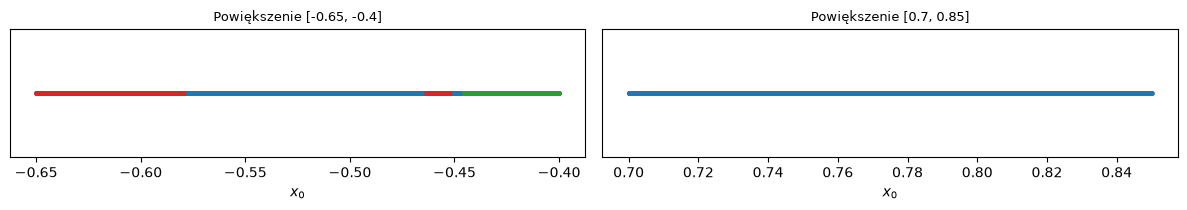

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 2.2))
for ax, (lo, hi) in zip(axes, [(-0.65, -0.40), (0.70, 0.85)]):
    x0_fine = np.linspace(lo, hi, 2000)
    wyniki_fine = np.array([klasyfikuj_start(fB, dfB, x0, korzenie) for x0 in x0_fine])
    for etykieta in [-1, 0, 1, 2]:
        maska = wyniki_fine == etykieta
        ax.scatter(x0_fine[maska], np.zeros(np.sum(maska)), c=kolory[etykieta], s=6)
    ax.set_yticks([])
    ax.set_xlabel('$x_0$')
    ax.set_title(f'Powiększenie [{lo}, {hi}]', fontsize=9)
plt.tight_layout()
plt.show()

## Ciekawostka: obszary zbieżności w płaszczyźnie zespolonej (fraktal Newtona)

To, co w 1D jest wąskim pasem przeplatających się kolorów, w płaszczyźnie **zespolonej** staje się w pełni rozwiniętym fraktalem -- to jeden z najbardziej znanych obrazów w numeryce. Rozwiążmy $z^3=1$ (trzy pierwiastki zespolone: $1$, $e^{2\pi i/3}$, $e^{-2\pi i/3}$), startując Newtona z każdego punktu siatki na płaszczyźnie zespolonej.

To wykracza poza program tego kursu (równania **rzeczywiste**), ale dobrze pokazuje, że zjawisko z poprzedniego wykresu nie jest przypadkowym artefaktem tej jednej funkcji -- to ogólna cecha metody Newtona blisko granic obszarów zbieżności.

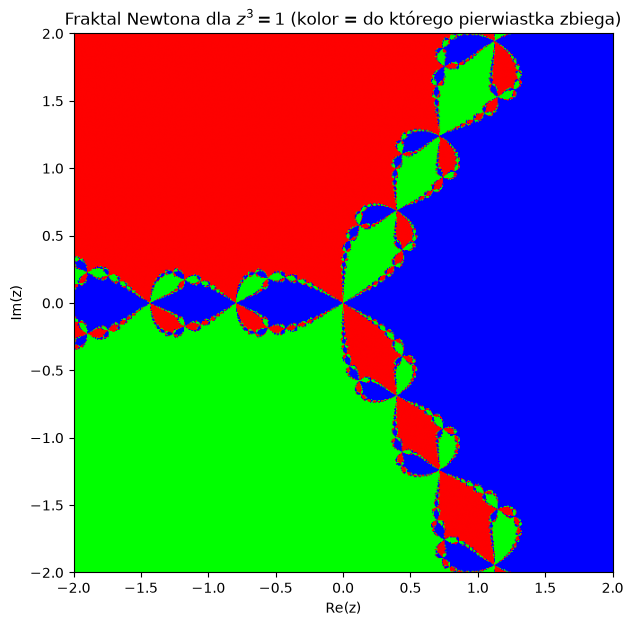

In [5]:
def fraktal_newtona(n=600, zakres=2.0, iteracje=25):
    x = np.linspace(-zakres, zakres, n)
    y = np.linspace(-zakres, zakres, n)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    Z[Z == 0] = 1e-9  # unikamy dzielenia przez zero dokładnie w środku siatki

    with np.errstate(divide='ignore', invalid='ignore'):
        for _ in range(iteracje):
            Z = Z - (Z**3 - 1) / (3 * Z**2)

    korzenie_zesp = np.array([1, np.exp(2j*np.pi/3), np.exp(-2j*np.pi/3)])
    # Dla każdego piksela: który z 3 pierwiastków jest najbliżej wyniku końcowego?
    odleglosci = np.abs(Z[..., None] - korzenie_zesp[None, None, :])
    przynaleznosc = np.argmin(odleglosci, axis=-1)
    przynaleznosc[~np.isfinite(Z)] = -1  # brak zbieżności (np. przez błąd numeryczny) -- czarny piksel
    return przynaleznosc, zakres

mapa, zakres = fraktal_newtona()
plt.figure(figsize=(7, 7))
plt.imshow(mapa, extent=(-zakres, zakres, -zakres, zakres), cmap='brg', origin='lower')
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.title('Fraktal Newtona dla $z^3=1$ (kolor = do którego pierwiastka zbiega)')
plt.show()

## Najważniejsze wnioski

- Wykładnik i stała lokalnej zbieżności ($\rho$, $C$) **nie gwarantują**, że metoda w ogóle zbiegnie -- to osobna właściwość, zależna od punktu startowego i kształtu funkcji.
- Cztery klasyczne niepowodzenia (rozbieżność, zbieżność do nieoczekiwanego pierwiastka, cykl, zerowa pochodna) mogą się zdarzyć nawet dla prostych, gładkich funkcji wielomianowych.
- Granica między obszarami zbieżności różnych pierwiastków nie jest w ogólności pojedynczym, prostym punktem -- może mieć złożoną strukturę, co w płaszczyźnie zespolonej przyjmuje postać w pełni rozwiniętego fraktala.
- W praktyce: **dobry punkt startowy ma znaczenie tak samo dużo, jak dobra metoda** -- stąd popularność strategii "globalizujących" zbieżność (damped Newton, bisekcja jako pierwszy krok przed przełączeniem na Newtona) wspomnianych w przeglądzie materiałów źródłowych (`TODO.md`, sekcja 4).

## Wykorzystywane funkcje

| Funkcja | Opis |
|---|---|
| `np.meshgrid(x, y)` | Buduje siatkę 2D współrzędnych z dwóch wektorów 1D |
| `np.errstate(divide='ignore', invalid='ignore')` | Wycisza ostrzeżenia numpy przy dzieleniu przez zero / `nan` (spodziewane przy iteracji na całej siatce) |
| `np.argmin(a, axis=-1)` | Indeks minimum wzdłuż ostatniej osi tablicy -- tu: który pierwiastek jest najbliżej |
| `plt.imshow(..., extent=...)` | Rysuje macierz jako obraz, z osiami przeskalowanymi do podanego zakresu |

## ĆWICZENIE

1. Zmień funkcję w sekcji "obszar zbieżności" na $f(x) = x^3 - 3x + 1$ (trzy pierwiastki rzeczywiste, w przybliżeniu $-1{,}88;\ 0{,}35;\ 1{,}53$) i powtórz sweep po $x_0\in[-3,3]$. Czy struktura granic między obszarami wygląda podobnie?
2. W czterech klasycznych przypadkach niepowodzeń (sekcja pierwsza) zmień punkt startowy $x_0$ tak, żeby każdy z czterech przykładów zaczął **zbiegać poprawnie** do najbliższego pierwiastka. Jak daleko trzeba było przesunąć $x_0$ w każdym przypadku?
3. W fraktalu Newtona zmień wielomian na $z^4=1$ (cztery pierwiastki) i dostosuj listę `korzenie_zesp`. Ile "płatków" ma teraz fraktal?